In [20]:
import os
import pickle as pkl
import random

import pandas as pd
import shap

from prepare_text_class import TextPrepareClass

shap.initjs()

In [2]:
DATA_PATH = os.path.join('.', 'data')
MODEL_PATH = os.path.join('.', 'models')

In [3]:
PHONES = r'\b(samsung|galaxy|xiaomi|iphon|redmi|note|honor|huawei|apple|' +\
          'nokia|meizu|google|самсунг|айфон|mi|lenovo|lg|redme|asus|vivo|' +\
          'zte|helio|mediatek|oppo|htc|pixel|xperia|fly|realme|zenfone|' +\
          'alcatel|blade|philips|touch|lumia|oneplus|motorola|inoi|red|neo|' +\
          'moto|panasonic|band|honnor|bbk|vertex|lafleur|xiomi|редми|хонор|' +\
          'ноки|хуаве|мейзу|асус|галакси|иной|гэлакси|хонор}' +\
          'pro|max|mini|ultra)(|[a-zа-я]+)' #\b

# Загружаю и предобрабатываю данные

In [4]:
textprepare = TextPrepareClass(PHONES)

In [5]:
data = pd.read_csv(os.path.join(DATA_PATH, 'ru_train.csv'))
data['text_cl'] = data.review.map(textprepare.clean_all)
data['target']  = data.rating.apply(lambda x: 0 if int(x) >= 4 else 1)

# Logreg

In [6]:
with open(os.path.join(MODEL_PATH, 'logreg_vektorizer.pkl'), 'rb') as fd:
    vectorizer = pkl.load(fd)

with open(os.path.join(MODEL_PATH, 'logreg_model.pkl'), 'rb') as fd:
    model = pkl.load(fd)

In [7]:
train = vectorizer.transform(data.text_cl)

Общее влияние токенов

In [8]:
f_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

positive_max = sorted([el for el in zip(f_names, coef)], key=lambda x: x[1], reverse=True)
negative_max = sorted([el for el in zip(f_names, coef)], key=lambda x: x[1], reverse=False)

In [34]:
positive_max[:10]

[('жас', np.float64(34.07660648941767)),
 (' сла', np.float64(17.884289729562063)),
 ('кат', np.float64(14.726083299838518)),
 ('нел', np.float64(14.48808800828511)),
 (' нев', np.float64(13.692758487183148)),
 ('нор', np.float64(12.083668184456794)),
 ('звон', np.float64(11.933303036640256)),
 ('рова', np.float64(11.563131660142046)),
 ('еуд', np.float64(11.393184099487378)),
 ('реза', np.float64(11.136298571399136))]

In [35]:
negative_max[:10]

[('тли', np.float64(-16.206749714186934)),
 (' сме', np.float64(-14.634289751682873)),
 (' ши', np.float64(-11.94250995167348)),
 (' ед', np.float64(-11.940894223939857)),
 ('ривы', np.float64(-11.932880396207372)),
 ('льз ', np.float64(-11.760379484133242)),
 ('ажн', np.float64(-11.732291212877445)),
 ('меч', np.float64(-11.314982206153799)),
 ('сем', np.float64(-9.287742312858155)),
 ('сво', np.float64(-9.091659211049786))]

In [11]:
explainer = shap.Explainer(model, train, feature_names=f_names)
shap_values = explainer(train)

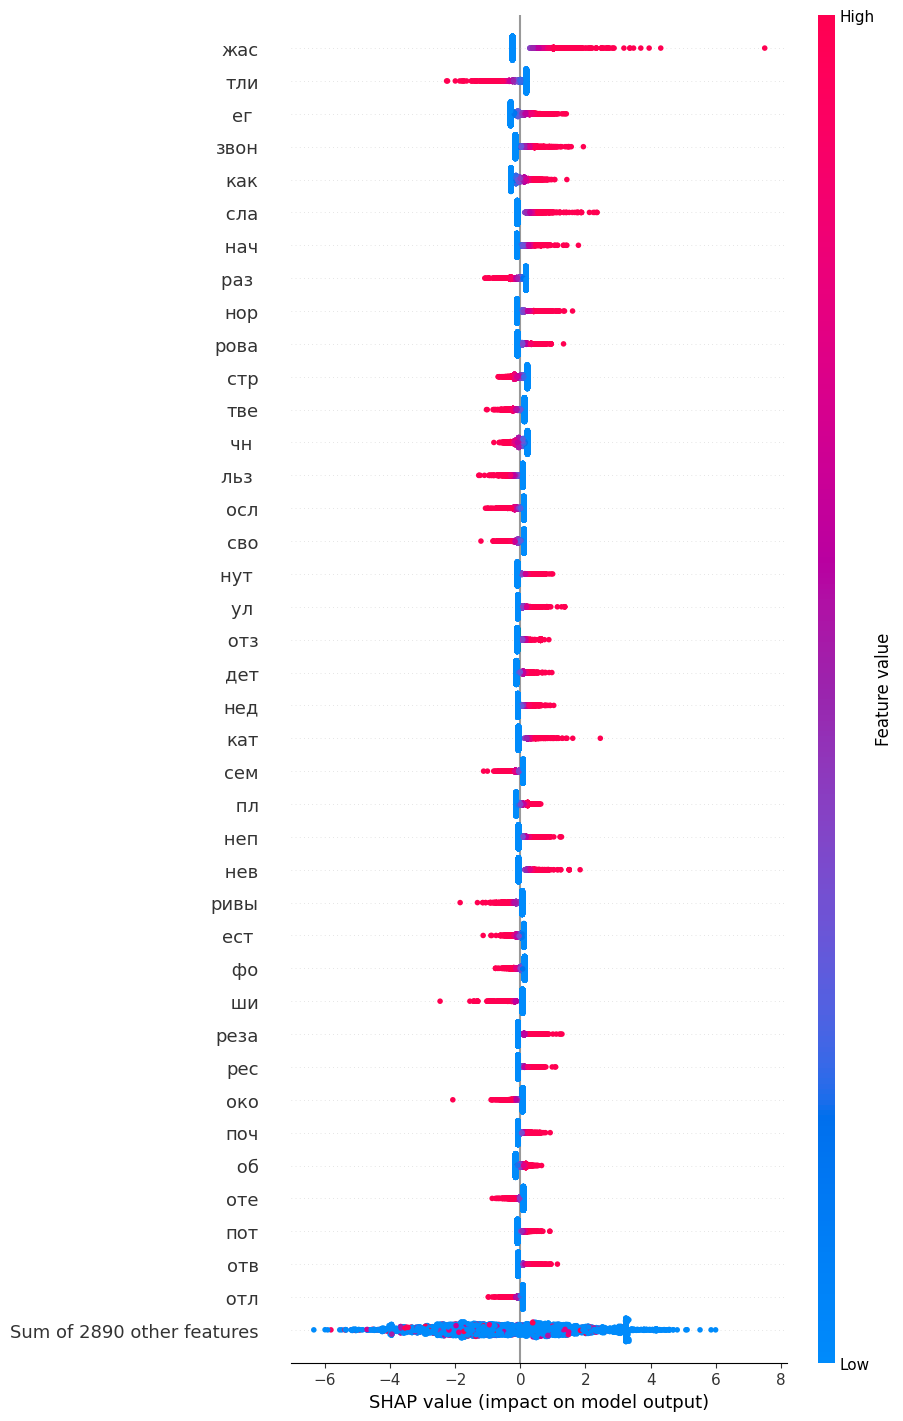

In [12]:
shap.plots.beeswarm(shap_values, max_display=40)

Объяснение ошибочных предсказаний

In [13]:
pred = model.predict(train)
data['pred'] = pred

In [31]:
error_indexes = data[data.target != data.pred].index
print(len(error_indexes))

480


In [44]:
tmp = random.choice(error_indexes)
if data.pred[tmp] == 1:
    ordr = shap.Explanation.argsort.flip,
else:
    ordr = shap.Explanation.argsort

In [46]:
data.review[tmp]

'Во время гонки по увеличению диагонали смартфонов "Samsung" решили выпустить смартфон с диагональю экрана 4,5 дюймов под названием "Samsung Galaxy J1". При столь малом экране он не может иметь высокую производительность, по этому его фишка это компактность. Имеется камера на 8 Мп, которая делает фото не очень высокого качества, может снимать видео с разрешением до 1080р. Так же имеется батарея на 2050 мАч, что в совокупности с небольшим экраном позволяет ему работать до 3 дней. У меня держит заряд около 2 дней.\nВесь корпус выполнен из пластика, что делает вес смартфона совсем лёгким. Что позволяет его носить куда угодно. Лично для меня это звонилка, т.к особо поиграть не получится, полноценно по сидеть в интернете тоже. Только по этому я сменил этот смартфон.'

In [48]:
№shap.plots.force(shap_values[tmp], )

SyntaxError: invalid character '№' (U+2116) (1193207675.py, line 1)

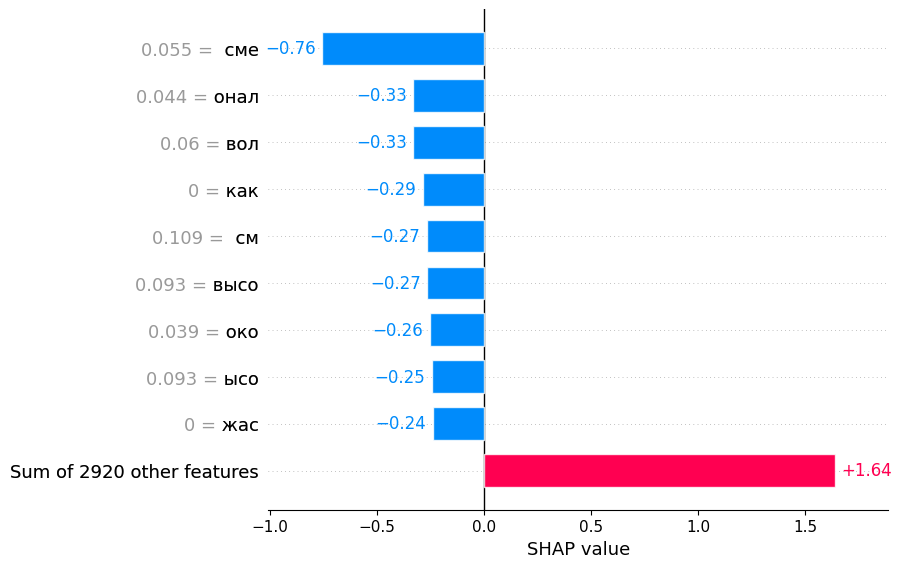

In [45]:
shap.plots.bar(shap_values[tmp], max_display=10,
               order=ordr,
               )

# CatBoostClassifier

In [8]:
with open(os.path.join(MODEL_PATH, 'catboost_vektorizer.pkl'), 'rb') as fd:
    vectorizer = pkl.load(fd)

with open(os.path.join(MODEL_PATH, 'catboost_model.pkl'), 'rb') as fd:
    model = pkl.load(fd)

In [32]:
train = vectorizer.transform(data.text_cl)

explainer = shap.TreeExplainer(model, feature_names=vectorizer.get_feature_names_out())
shap_values = explainer(train)

Общее влияние токенов

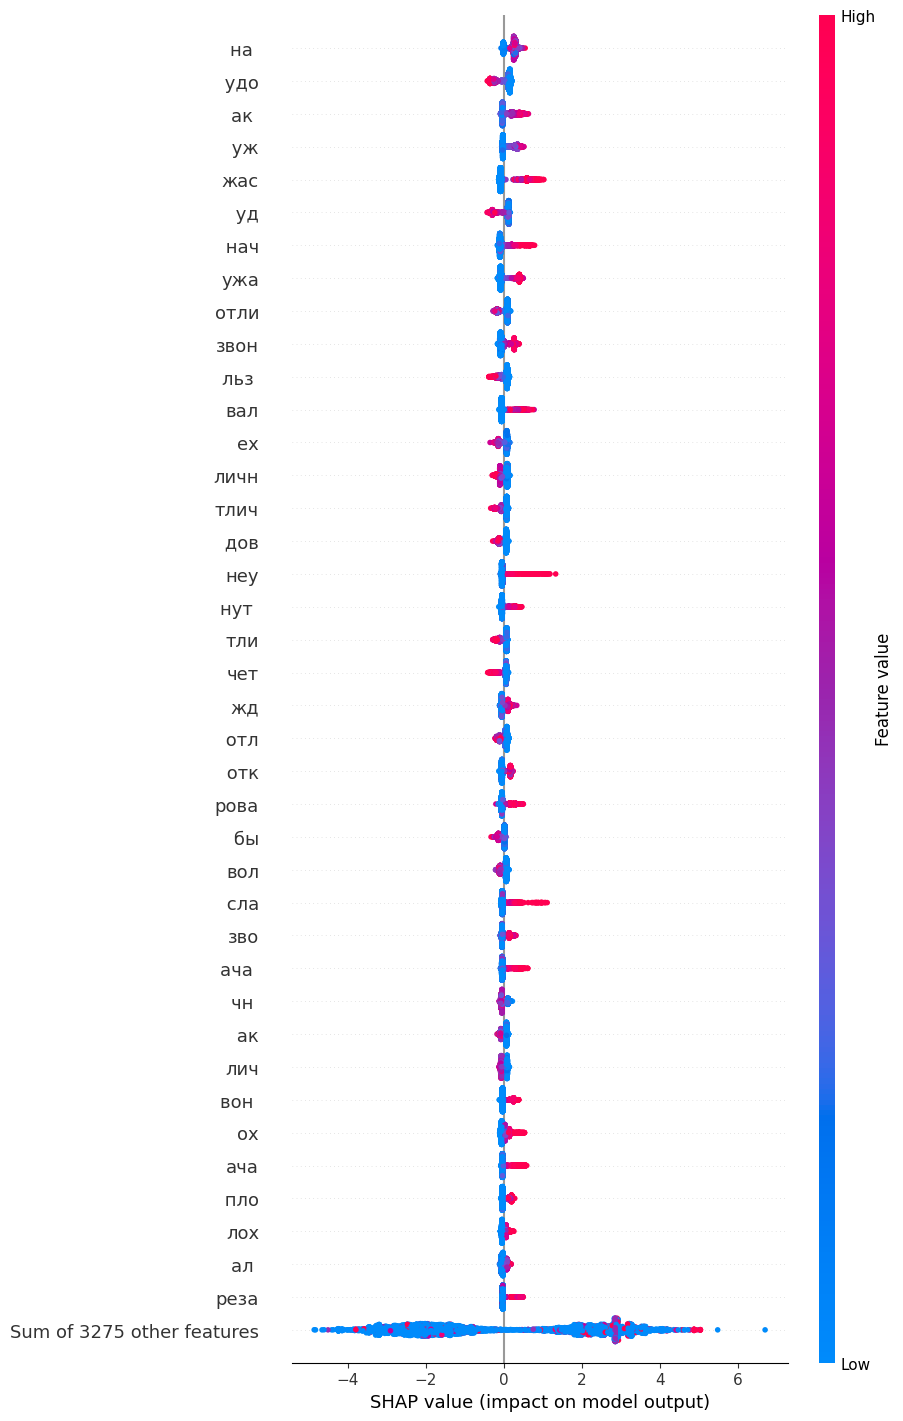

In [33]:
shap.plots.beeswarm(shap_values, max_display=40)